#### Name: Ben Maxwell

# PHYS 230 Lab Assignment 15

### Wednesday, April 1, 2026: Chapter 8.2-8.3
- Multivariable differential equations
- Second-order differential equations 

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a second-order ordinary differential equation for a simple harmonic oscillator. The standard equation is given as: 

$$\frac{d^2x}{dt^2}= -\omega^2 x $$

The general solution to this differential equation is: 

$$x(t) = c_1 \cos \omega t + c_2 \sin \omega t $$

where $c_1$ and $c_2$ can be found from initial conditions. 

For this problem, we will analyze the case of $\omega = 1$ in the range of $t=0$ to $t=50$. The initial conditions are $x=1$ and $dx/dt = 0$. 

*Problem adapted from Exercise 8.6 in the textbook*

### Part 1: Solving the second-order differential equation 

Let's solve for $x$ as a function of time. Do this in the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. 
*Double-check with the professor before moving on.*

$$  \frac{dx}{dt} = v  $$

$$  \frac{dv}{dt} = -\omega^2x  $$

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1. 

In [32]:
#Define functions

def f(r,t):
    # r = np.array([x,y])
    x = r[0]
    v = r[1]

    # define actual differential equations
    fx = v
    fv = -(omega**2)*x

    #return vector array of functions
    return np.array([fx,fv], float)

In this code, I define a function that takes an array r and value t. Then, it sets x equal to the first part of the array, and v equal to the second part of the array. Then, I calculate dx/dt (which is represented as fx) and dv/dt (which is represented as fv). Finally, I return an array with fx and fv. 

#### Step 3: Write a function `RK4_multi(r,t,h,f)` - like you did in the last lab - that you can use to solve any two simultaneous single-order differential equations.  

In [33]:
def RK4_multi(r,t,h,f):
    # create arrays to keep track of x,y values
    xpts = np.zeros(len(t))
    ypts = np.zeros(len(t))
    # loop to apply fourth order runge-kutta
    for i in range(len(t)):
        xpts[i] = r[0]
        ypts[i] = r[1]
        k1 = h*f(r,t[i])
        k2 = h*f(r+0.5*k1,t[i]+0.5*h)
        k3 = h*f(r+0.5*k2,t[i]+0.5*h)
        k4 = h*f(r+k3,t[i]+h)
        r+= (k1+2*k2+2*k3+k4)/6
    return xpts, ypts

In this code, I create a user defined function, which takes r, t, h, f. Then, it creates two arrays for xpts and ypts that are the length of t. Then it goes through a range the length of t, and at each point adds the respective values to xpts and ypts. Then, it calculates k1, k2, k3, and k4, and finally adds (k1+2 * k2+2 * k3+k4)/6 to r. 

#### Step 4: Define any constants and arrays necessary for the problem and solve for $x$ and $dx/dt$ as a function of time. 

In [34]:
#Define initial conditions + constants
tstart = 0
tend = 50
Nsteps = 1000
h = (tend-tstart)/Nsteps
tpts = np.arange(tstart, tend+h, h)
omega = 1 

r = np.array([1,0], float)


In this I define all the given constants, and create an array r where the first value is the initial condition for x and the second is initial conditions for v. 

#### Step 5: Make a plot the position $x$ vs. time. Does this agree with what you expected (add a markdown cell explaining this)? 

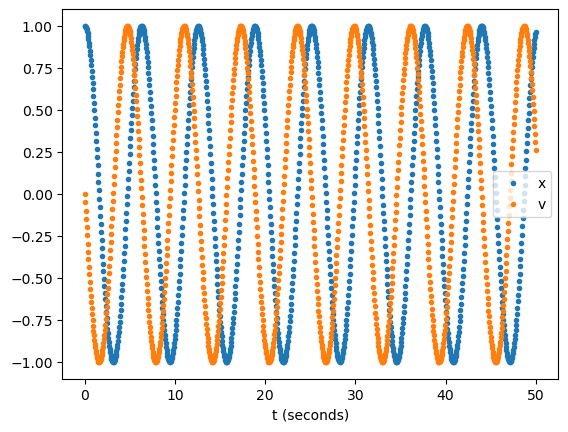

In [14]:

xpts, ypts = RK4_multi(r, tpts, h, f)

#Make plot of results
plt.plot(tpts, xpts, ".")
plt.plot(tpts, ypts, ".")
plt.legend(["x","v"])
plt.xlabel("t (seconds)")
plt.show()

All I did for this is call upon my RK4 function, and then use plt.plot to plot it. I added a legend and labels through the graph. 

#### Step 6: Now graph $dx/dt$ vs. $x$ instead. This is called a *phase space* plot. Interpret the result (do an internet search to understand phase space plots if need be, but your explanations must be in your own words). 

If you would like to make your graph square, you can use: 
`plt.figure(figsize=(#,#))` replacing the #'s with whatever equal dimensions you want. 

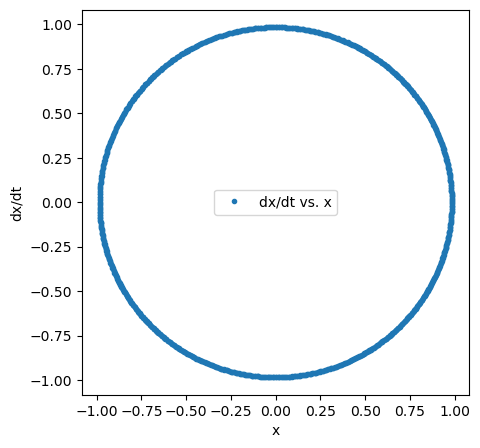

In [39]:
xpts, ypts = RK4_multi(r, tpts, h, f)

#Make plot of results
plt.figure(figsize=(5,5))
plt.plot(xpts, ypts, ".")
plt.legend(["dx/dt vs. x"])
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.show()

For this code, I once again called on the function. When called upon I set xpts as x and ypts as dx/dt. Then, I created a plot with ypts on the xaxis and xpts on the yaxis (which can be a little confusing.). I updated my figure size and added labels everywhere.

### Part 2: Variations

Test what happens to your solution when we change some parameters. 

#### Step 1: Increase the amplitude of oscillators by making the initial position larger. Reanalyze the results and plot $x$ vs. $t$ again. What can you say about the oscillations? In particular, comment on the period of oscillations - what do we expect to happen to the period when the amplitude is increased?  

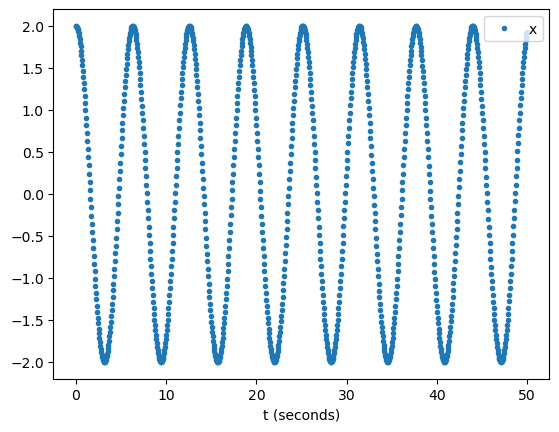

In [44]:
#Define initial conditions + constants
tstart = 0
tend = 50
Nsteps = 1000
h = (tend-tstart)/Nsteps
tpts = np.arange(tstart, tend+h, h)
omega = 1 

r = np.array([2,0], float)

xpts, ypts = RK4_multi(r, tpts, h, f)

#Make plot of results
plt.plot(tpts, xpts, ".")
plt.legend(["x","v"])
plt.xlabel("t (seconds)")
plt.show()

When the amplitude is increased, nothing changes about the oscillations except that they start from a higher point, and have a bigger amplitude. Specifically with the peroid, it doesn't change no matter the amplitude. 

#### Step 2: Using the original amplitude, change the initial conditions to be $x = 0$ and $dx/dt = 1$. Analyze the results and plot position vs. time again. What do you notice about the oscillations compared to the previous step and the original in Part 1?

(You may find it helpful to plot the original results from Part 1 simultaneously on the same graph for comparison)

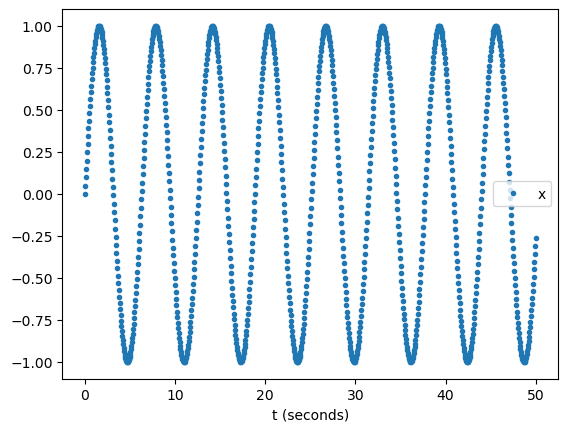

In [43]:
#Define initial conditions + constants
tstart = 0
tend = 50
Nsteps = 1000
h = (tend-tstart)/Nsteps
tpts = np.arange(tstart, tend+h, h)
omega = 1 

r = np.array([0,1], float)

xpts, ypts = RK4_multi(r, tpts, h, f)

#Make plot of results
plt.plot(tpts, xpts, ".")
plt.legend(["x","v"])
plt.xlabel("t (seconds)")
plt.show()

The graph is very similar, with the same amplitude and period of oscilations, however the graphs are offset from each other, which is the main difference. 

### Part 3: Anharmonic Oscilator 

Let's now analyze the motion of an anharmonic oscillator described by the equations
$$ \frac{d^2x}{dt} = -\omega^2 x^3 $$
Again, analyze the case of $\omega = 1$ in the range of $t=0$ to $t=30$. The initial conditions are $x=1$ and $dx/dt = 0$. 

#### Step 1: Make a graph of $x$ vs. $t$ by applying steps 1-5 from part 1 above for this new equation. 
**Hint**: You can/should reuse your `RK4_Multi` function rather than coding it up again, but be sure to complete all 5 steps 

$$\frac{dx}{dt} = v $$
$$\frac{dv}{dt} = -\omega^2x^3 $$

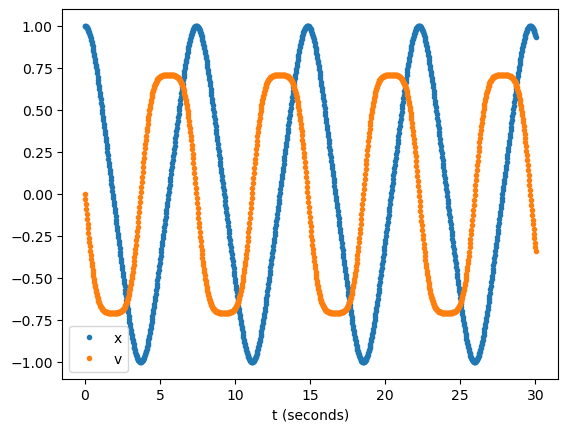

In [36]:
#Define functions

def f3(r,t):
    # r = np.array([x,y])
    x = r[0]
    v = r[1]

    # define actual differential equations
    fx = v
    fv = -(omega**2)*(x**3)

    #return vector array of functions
    return np.array([fx,fv], float)

#Define initial conditions + constants
tstart = 0
tend = 30
Nsteps = 1000
h = (tend-tstart)/Nsteps
tpts = np.arange(tstart, tend+h, h)
omega = 1 

r = np.array([1,0], float)

#Calling on the function

xpts, ypts = RK4_multi(r, tpts, h, f3)

#Make plot of results
plt.plot(tpts, xpts, ".")
plt.plot(tpts, ypts, ".")
plt.legend(["x","v"])
plt.xlabel("t (seconds)")
plt.show()


In this code, I start by defining f3, which is just the same function as f but instead dv/dt equals -w^2x^3. Then, I added my initial conditions which are all the same as before, except it's from t=0 to t= 30 instead of t=0 to t=50. Finally, I called on my RK4 function and plotted it in the graph. 

#### Step 2: Once again, vary the amplitude to see what happens when we increase the amplitude from $x=1$ to $x=2$ to $x=4$. Plot all three position vs. time graphs on the same graph (be sure to include a legend). What do you notice about an anharmonic oscillator as the amplitude increases? 

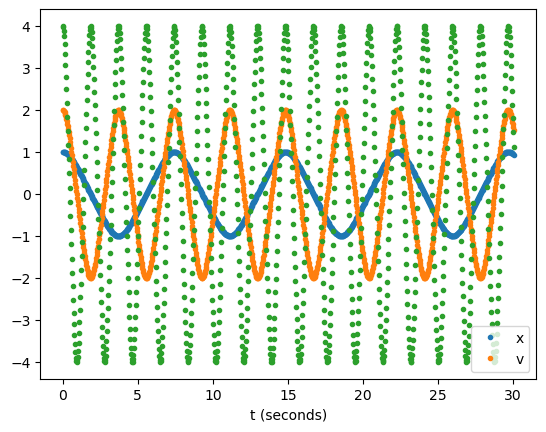

In [42]:
#Define initial conditions + constants
tstart = 0
tend = 30
Nsteps = 1000
h = (tend-tstart)/Nsteps
tpts = np.arange(tstart, tend+h, h)
omega = 1 

r = np.array([1,0], float)

#Calling on the function

xpts, ypts = RK4_multi(r, tpts, h, f3)

#Make plot of results
plt.plot(tpts, xpts, ".")

#Changing the positions
r = np.array([2,0], float)

#Calling on the function

xpts, ypts = RK4_multi(r, tpts, h, f3)

#Make plot of results
plt.plot(tpts, xpts, ".")
r = np.array([4,0], float)

#Calling on the function

xpts, ypts = RK4_multi(r, tpts, h, f3)

#Make plot of results
plt.plot(tpts, xpts, ".")


plt.legend(["x","v"])
plt.xlabel("t (seconds)")
plt.show()


As the Amplitude increases the oscilations also increase.  The period also decreases greatly at each increase in amplitude.  

#### Step 3: Now graph the *phase space* plot of the anharmonic oscillator. Include the phase space of the harmonic oscillator. In markdown, interpret the result and compare with the harmonic oscillator phase space plot. (Do this for the *original* initial conditions - they need to be the same to properly compare)

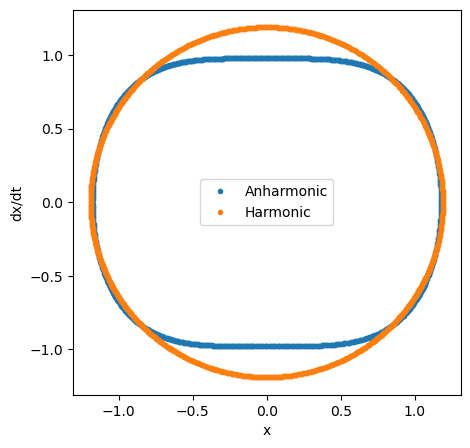

In [41]:
#Calling on the function

xpts3, ypts3 = RK4_multi(r, tpts, h, f3)
xpts, ypts = RK4_multi(r, tpts, h, f)


#Make plot of results
plt.figure(figsize=(5,5))
plt.plot(xpts3, ypts3, ".")
plt.plot(xpts, ypts, ".")
plt.legend(["Anharmonic","Harmonic"])
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.show()


In this part, I graphed the harmonic and anharmic on the phase space plot. This was done by calling on the function once again, and then just graphing the xpts and ypts against each other. In this scenario, since I called on the function twice, I used xpts3 and ypts3 for the anharmonic. Based on this graph, it can be see how the positions and velocities of the oscilator are very similar near the mins and max positions, and very different near the origin. 